<h1>NAO Index</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)
    
from src.datareader import datareader as dr
from src.util import util, stats

<h5>User Configurables</h5>

In [3]:
ufs_experiment = 'c96_beta.0.1'
ufs_var = 'prmsl'
era5_var = 'mean_sea_level_pressure'
time_range = ("1994-01-01", "2021-12-31T23")
initmonths = (11,)

# For NAO, there are 2 reference locations:
region_1 = {'latmin': 37.7, 'lonmin': 334.3}
region_2 = {'latmin': 65.0, 'lonmin': 331.2}

<h5>Get data readers</h5>

In [4]:
ufs_data_reader = dr.getDataReader(datasource='UFS',
                                   #filename=f"experiments/phase_1/{ufs_experiment}/atm_monthly.zarr",
                                   experiment=ufs_experiment,
                                   model='atm')

era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/c96_beta.0.1/atm_monthly.zarr
No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [5]:
ufs_data_reader.describe(ufs_var)


Variable: prmsl
Dimensions: ('init', 'lead', 'member', 'lat', 'lon')
Shape: (60, 12, 11, 181, 360)
Attributes:
  - long_name: Pressure reduced to MSL
  - units: Pa


In [6]:
era5_data_reader.describe(era5_var)


Variable: mean_sea_level_pressure
Dimensions: ('time', 'lat', 'lon')
Shape: (92044, 256, 512)
Attributes:
  - long_name: Mean sea level pressure
  - short_name: msl
  - standard_name: air_pressure_at_mean_sea_level
  - units: Pa


<h5>Get the monthly climatology for nino 3.4</h5>

In [7]:
# Enter a list of members, like [1, 2, 6, 8, ens_avg]
# Note that 'ens_avg' is a special keyword in the ensuing code.
# If you include 'ens_avg' in the list of members,
# then the Ensemble Average will be listed under member = -1
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'ens_avg']

In [8]:
%%capture captured_output
# This function combines member data with a computed ens_avg member.
ufs_ds_1 = util.retrieve_ufs_dataset(ufs_data_reader, ufs_var, time_range, members,
                                     region_1, initmonths=initmonths)

ufs_ds_2 = util.retrieve_ufs_dataset(ufs_data_reader, ufs_var, time_range, members,
                                     region_2, initmonths=initmonths)


<h5>Get the corresponding ERA5 data</h5>

In [9]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                lat=region_1['latmin'],
                lon=region_1['lonmin'],
                time=time_range)

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                lat=region_2['latmin'],
                lon=region_2['lonmin'],
                time=time_range)

<h5>Calculate climatologies for each dataset (this may take a couple minutes)</h5>

In [10]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=False)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=False)

In [11]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [12]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_var], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_var], stats=ufs_stats_2)

In [13]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h2>Calculate NAO Index</h2>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [14]:
ufs_da_1 = ufs_da_1.squeeze(['lat', 'lon'])  # flatten
ufs_da_2 = ufs_da_2.squeeze(['lat', 'lon'])
era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])

In [15]:
ufs_ds_diff = (ufs_da_2 - ufs_da_1).to_dataset()
era5_ds_diff = (era5_da_2 - era5_da_1).to_dataset()

<h2>Plot NAO Index</h2>

Generating 4 panel(s).
Processing years 1994 to 1999
Processing years 2000 to 2009
Processing years 2010 to 2019
Processing years 2020 to 2021


<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/ufs_py311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

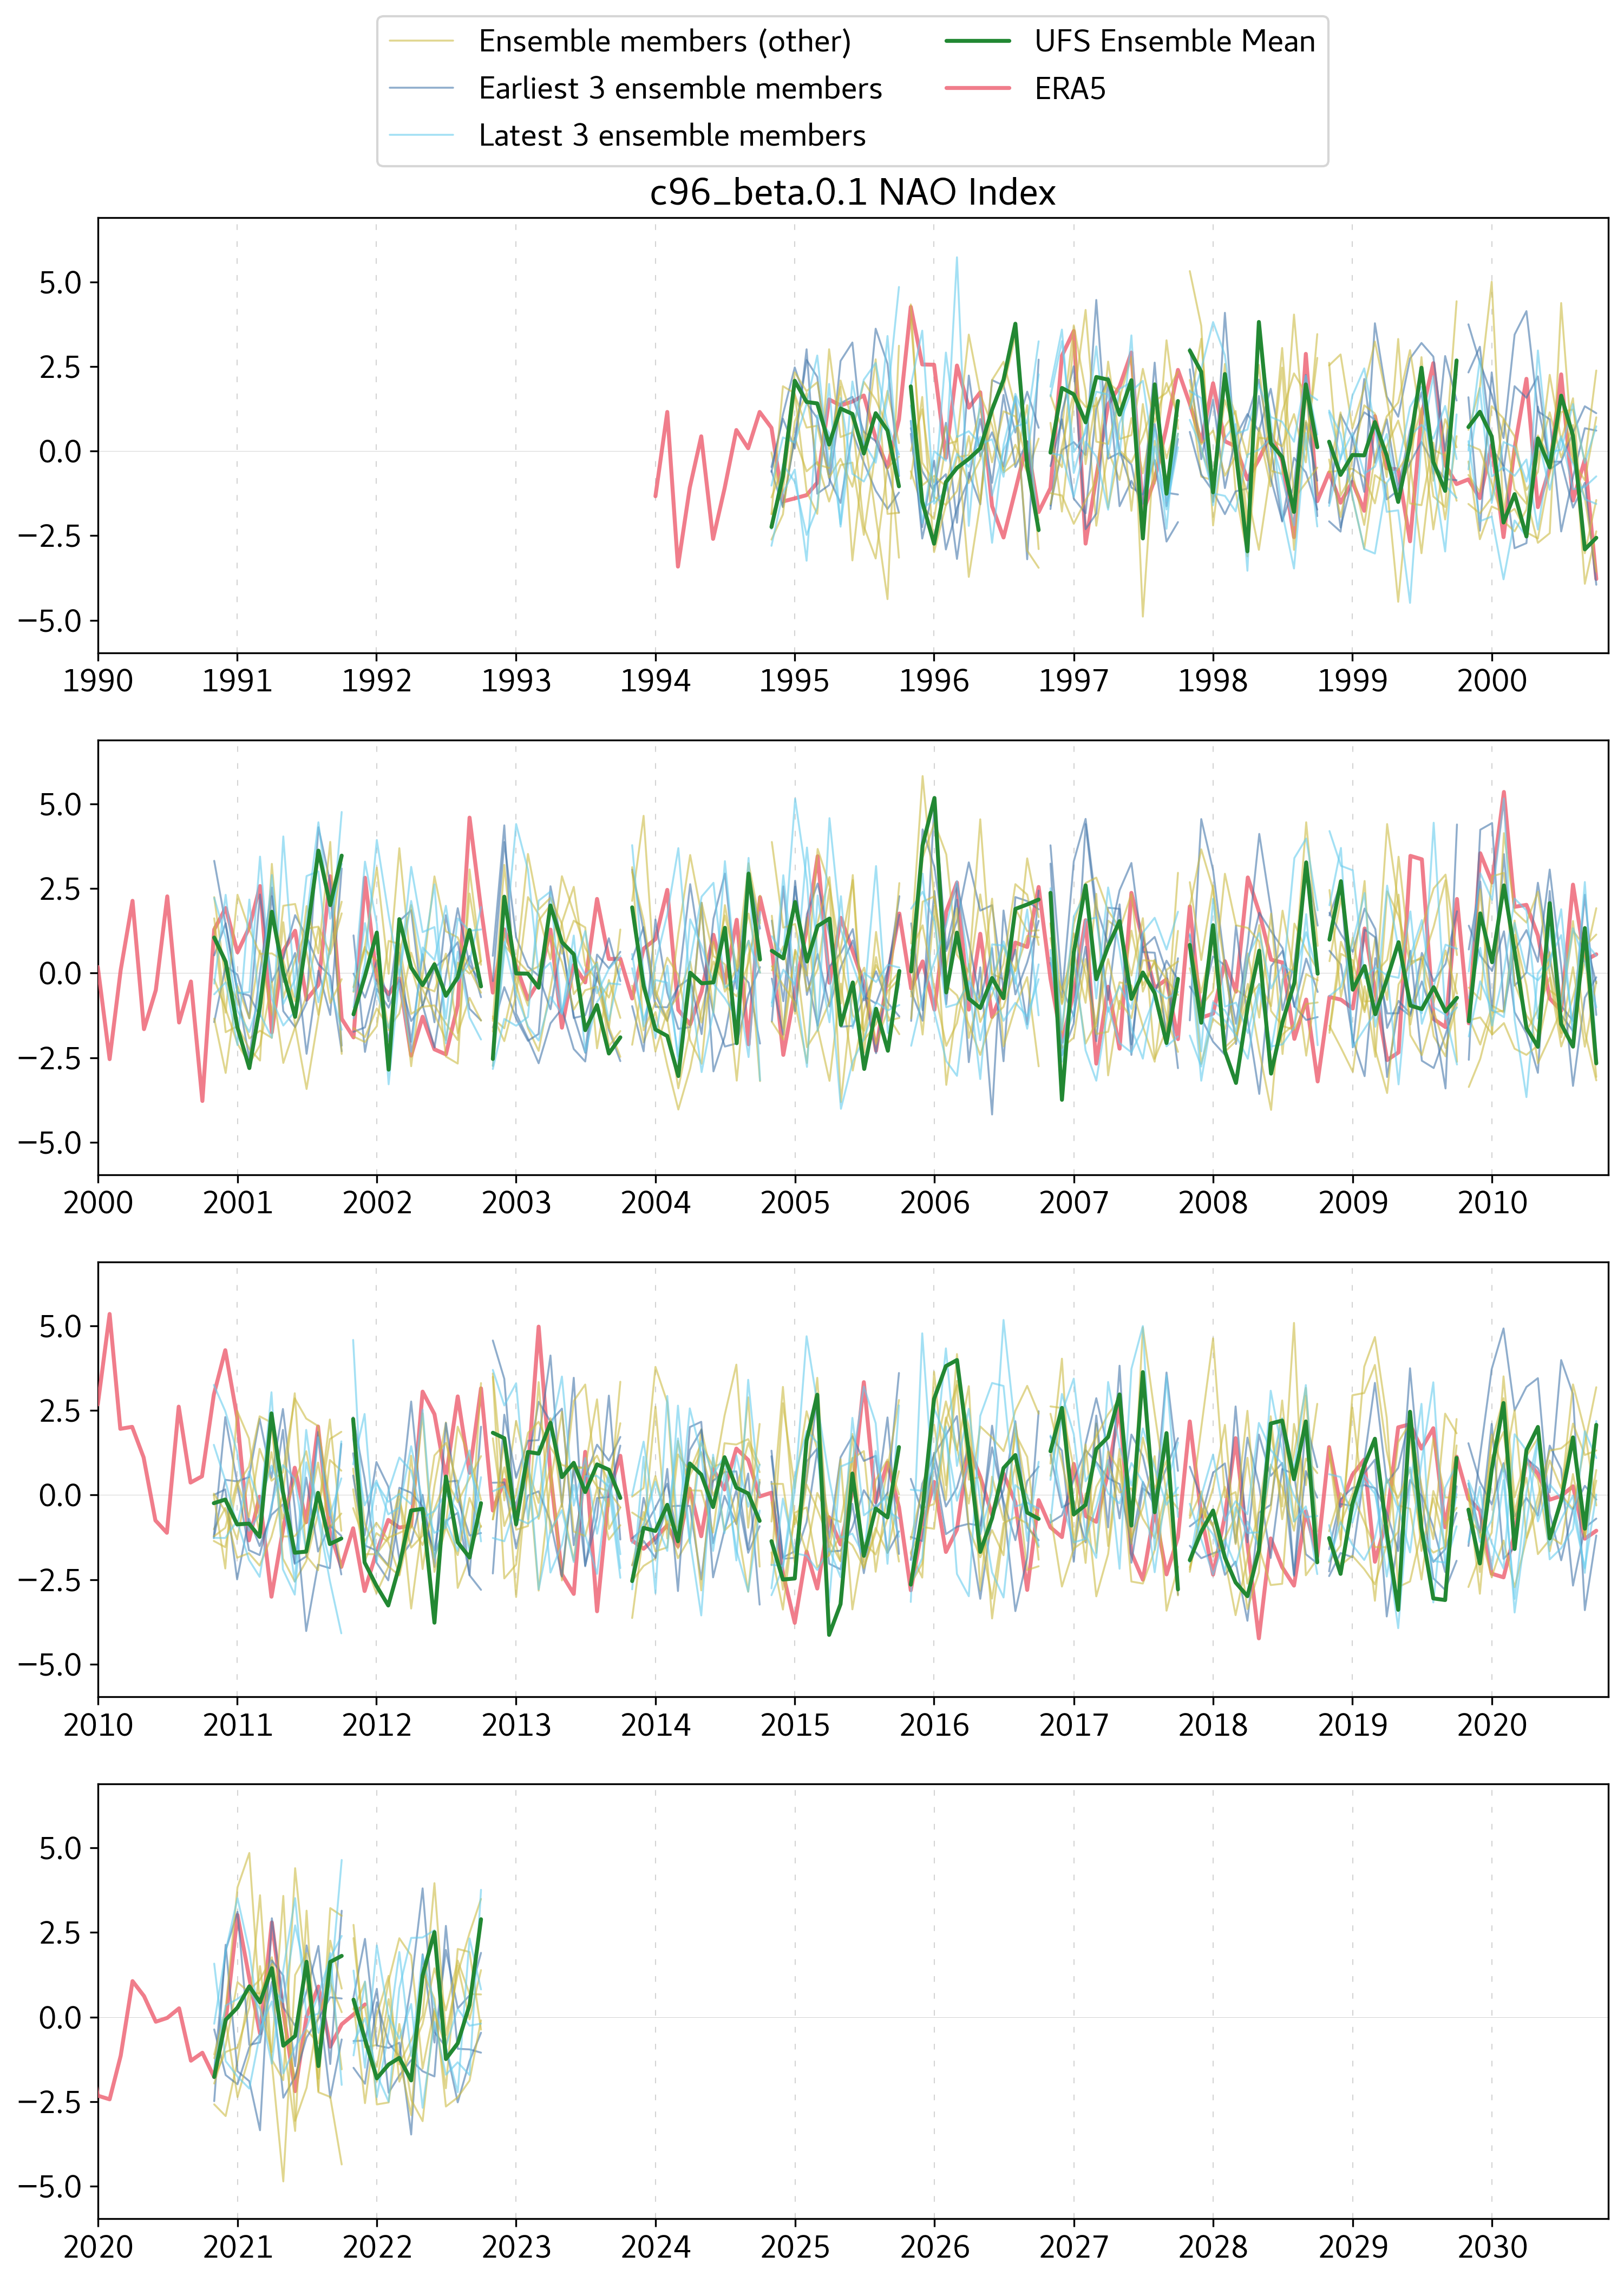

In [16]:
stats.plot_index_spaghetti(ufs_stats={'monthly_mean': ufs_ds_diff[ufs_var]},
                           verif_stats={'monthly_mean': era5_ds_diff[era5_var]},
                           calc_anomaly=False,
                           use_member_climatology=False,
                           title=f'{ufs_experiment} NAO Index',
                           verif_label='ERA5',
                           dpi=300)